# CIFAR-10 Image Classifier

## 1 Dataset

In [1]:
# Import dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Load and preprocess CIFAR-10 dataset
def load_data_cifar_10(batch_size, resize=None):
  # Data augmentation for training
  train_trans = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 normalization (specific means and stds)
  ])

  # Basic transformation for test data
  test_trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
  ])

  # Load training and test datasets
  cifar_train = torchvision.datasets.CIFAR10(
      root="./data", train=True, transform=train_trans, download=True)
  cifar_test = torchvision.datasets.CIFAR10(
      root="./data", train=False, transform=test_trans, download=True)

  # Return DataLoaders
  return (torch.utils.data.DataLoader(cifar_train, batch_size, shuffle=True, num_workers=2),
          torch.utils.data.DataLoader(cifar_test, batch_size, shuffle=False, num_workers=2))

In [4]:
# Load data
batch_size = 64
train_iter, test_iter = load_data_cifar_10(batch_size)

## 2 Architecture

In [5]:
# Define intermediate block
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super(IntermediateBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_convs = num_convs

        # Convolutional layers
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            for _ in range(num_convs)
        ])

        # Dropout, batch norm, and ReLU activation function
        self.dropout = nn.Dropout(0.3)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        # Fully connected layer
        self.fc = nn.Linear(in_channels, num_convs)

        # Residual connection (1x1 convolution if dimensions mismatch)
        self.residual_conv = None
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        batch_size = x.size(0)

        # Apply each convolution to the input
        conv_outputs = [conv(x) for conv in self.convs]

        # Compute weights
        m = torch.mean(x, dim=[2, 3])  # Global average pooling
        a = self.fc(m)  # Apply fully connected layer to pooled features
        a = F.softmax(a, dim=1)  # Softmax normalization to get weights

        # Weighted sum of convolution outputs
        x_prime = torch.zeros_like(conv_outputs[0])
        for i in range(self.num_convs):
            weight = a[:, i].view(batch_size, 1, 1, 1)
            x_prime += weight * conv_outputs[i]

        # Apply dropout and batch norm
        x_prime = self.dropout(x_prime)
        x_prime = self.bn(x_prime)

        # Add skip connection if needed
        if self.residual_conv:
            x = self.residual_conv(x)  # Match dimensions
        x_prime += x

        # Apply ReLU activation
        x_prime = self.relu(x_prime)

        return x_prime

In [6]:
# Define full CNN classifier
class Net(nn.Module):
    def __init__(self, block_configs, fc_layers=0):
        super(Net, self).__init__()

        # Initial convolution layer
        self.initial_conv = nn.Conv2d(3, block_configs[0][0], kernel_size=3, padding=1)
        self.initial_bn = nn.BatchNorm2d(block_configs[0][0])
        self.initial_relu = nn.ReLU()

        # Intermediate blocks
        self.blocks = nn.ModuleList([
            IntermediateBlock(in_ch, out_ch, num_convs)
            for in_ch, out_ch, num_convs in block_configs
        ])

        # Number of output channels from the last intermediate block
        self.final_channels = block_configs[-1][1]

        # Output block
        output_layers = []
        in_features = self.final_channels

        # Intermediate fully connected layers
        for i in range(fc_layers):
            out_features = in_features // 2
            output_layers.append(nn.Linear(in_features, out_features))
            output_layers.append(nn.ReLU())
            output_layers.append(nn.Dropout(0.5))
            in_features = out_features

        # Final classification layer
        output_layers.append(nn.Linear(in_features, 10))
        self.output_block = nn.Sequential(*output_layers)

    def forward(self, x):
        # Initial convolution
        x = self.initial_conv(x)
        x = self.initial_bn(x)
        x = self.initial_relu(x)

        # Pass through intermediate blocks
        for i, block in enumerate(self.blocks):
            x = block(x)
            # Add max pooling after each block
            if i < len(self.blocks) - 1:
                x = F.max_pool2d(x, kernel_size=2, stride=2)

        # Global average pooling
        x = torch.mean(x, dim=[2, 3])

        # Pass through output block to get logits
        logits = self.output_block(x)
        return logits

In [7]:
# Weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [8]:
# Block configuration
block_configs = [
    (64, 128, 2),    # Block 1
    (128, 256, 2),   # Block 2
    (256, 512, 3),   # Block 3
    (512, 768, 3),   # Block 4
]

# Instantiate model
model = Net(block_configs, fc_layers=1)
model.apply(init_weights)
model = model.to(device)

## 3 Training and testing

In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()

In [10]:
# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [11]:
# Evaluation functions
def correct(logits, y):
    y_hat = logits.argmax(axis=1)
    return (y_hat == y).float().sum()

def evaluate_metric(model, data_iter, metric):
    model.eval()
    c = 0.
    n = 0.
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            c += metric(logits, y)
            n += len(y)
    return float(c / n)

print(f'Training accuracy: {evaluate_metric(model, train_iter, correct)}. Testing accuracy: {evaluate_metric(model, test_iter, correct)}.')

Training accuracy: 0.06737999618053436. Testing accuracy: 0.06480000168085098.



Epoch 1/50.
Average training loss: 2.6267
New best model saved with test accuracy: 0.1639
Training accuracy: 0.1645. Testing accuracy: 0.1639. Duration: 75.082s.

Epoch 2/50.
Average training loss: 1.9438
New best model saved with test accuracy: 0.2276
Training accuracy: 0.2497. Testing accuracy: 0.2276. Duration: 74.178s.

Epoch 3/50.
Average training loss: 1.7910
New best model saved with test accuracy: 0.3202
Training accuracy: 0.3291. Testing accuracy: 0.3202. Duration: 74.143s.

Epoch 4/50.
Average training loss: 1.7095
New best model saved with test accuracy: 0.3544
Training accuracy: 0.3723. Testing accuracy: 0.3544. Duration: 73.957s.

Epoch 5/50.
Average training loss: 1.3994
New best model saved with test accuracy: 0.5206
Training accuracy: 0.5365. Testing accuracy: 0.5206. Duration: 74.280s.

Epoch 6/50.
Average training loss: 1.1370
New best model saved with test accuracy: 0.6404
Training accuracy: 0.6502. Testing accuracy: 0.6404. Duration: 74.290s.

Epoch 7/50.
Average t

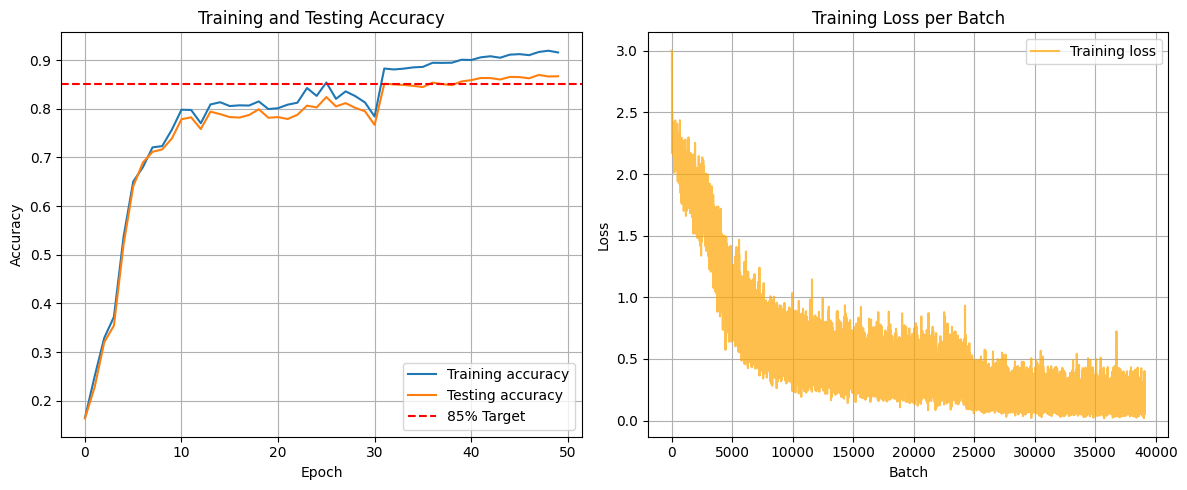

In [12]:
# Training loop
train_accs, test_accs, batch_losses = [], [], [] # Lists to store training accuracies, testing accuracies, and training loss
best_test_acc = 0.0  # Store best test accuracy
num_epochs = 50  # Number of epochs

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}.')
    start_time = time.perf_counter()

    # Training phase
    model.train()
    epoch_loss = 0.0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_losses.append(loss.item())  # Store batch loss

    # Print average loss for the epoch
    avg_epoch_loss = epoch_loss / len(train_iter)
    print(f'Average training loss: {avg_epoch_loss:.4f}')

    # Reduce learning rate after epoch 30
    if epoch == 30:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.1
            print(f"Reduced learning rate to {param_group['lr']}")

    # Evaluation phase
    train_acc = evaluate_metric(model, train_iter, correct)
    test_acc = evaluate_metric(model, test_iter, correct)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Save model if test accuracy improves
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar10_model_simple.pth')
        print(f'New best model saved with test accuracy: {best_test_acc:.4f}')

    end_time = time.perf_counter()
    print(f'Training accuracy: {train_acc:.4f}. Testing accuracy: {test_acc:.4f}. Duration: {end_time - start_time:.3f}s.')

# Load and evaluate the best model
model.load_state_dict(torch.load('best_cifar10_model_simple.pth'))
final_test_acc = evaluate_metric(model, test_iter, correct)
print(f'Final best model testing accuracy: {final_test_acc:.4f}')

# Plot training and testing accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Training accuracy')
plt.plot(test_accs, label='Testing accuracy')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Target')
plt.legend(loc='best')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.grid(True)

# Training loss plot
clipped_losses = [min(loss, 3) for loss in batch_losses]  # Clip extreme losses for better visualization
plt.subplot(1, 2, 2)
plt.plot(clipped_losses, label='Training loss', color='orange', alpha=0.7)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training Loss per Batch')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()